These are in the form [lam, a2, b1, b3, b5, c1, c2, c3, r_g, K_l, a3, b2, b4, Eh]
Fits:
Best fit, not best stability [7.18000191e+00 3.90613857e-03 1.65339085e+00 7.26296455e-03
 2.65769887e-01 1.45406889e-05 8.10024894e-03 4.41319261e-01
 1.49504701e+00 1.81012354e+03 3.85869716e-01 2.20611557e-01
 2.14437533e-01 7.27467408e-01]

 Better stability, not as good of a fit [5.43540252e+00 2.16826280e-04 3.24519120e+00 2.34954469e-03
 1.77551004e-01 1.65991457e-02 1.65504030e-02 1.71339813e-01
 1.12556378e+00 6.98983887e+02 4.11965138e-01 7.23381101e-02
 2.11326875e+00 9.18907272e-01]


Starting Pass 1 (20000 samples)...
Pass 1: 10% complete. Valid: 4
  Failures -> Extinction: 1159, Structural: 25, Stability: 16
Pass 1: 20% complete. Valid: 6
  Failures -> Extinction: 2314, Structural: 45, Stability: 37
Pass 1: 30% complete. Valid: 6
  Failures -> Extinction: 3428, Structural: 66, Stability: 56
Pass 1: 40% complete. Valid: 8
  Failures -> Extinction: 4579, Structural: 92, Stability: 74
Pass 1: 50% complete. Valid: 8
  Failures -> Extinction: 5722, Structural: 114, Stability: 86
Pass 1: 60% complete. Valid: 14
  Failures -> Extinction: 6911, Structural: 128, Stability: 101
Pass 1: 70% complete. Valid: 16
  Failures -> Extinction: 8058, Structural: 148, Stability: 115
Pass 1: 80% complete. Valid: 16
  Failures -> Extinction: 9193, Structural: 170, Stability: 128
Pass 1: 90% complete. Valid: 20
  Failures -> Extinction: 10380, Structural: 181, Stability: 138
Pass 1: 100% complete. Valid: 25
  Failures -> Extinction: 11561, Structural: 195, Stability: 151
Pass 1 Best: 0.4

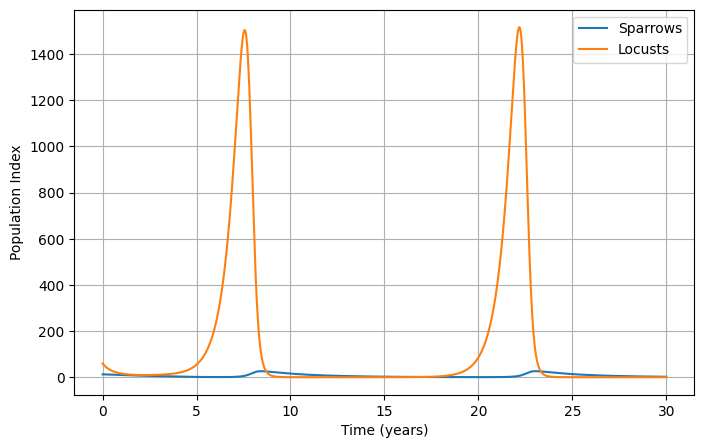

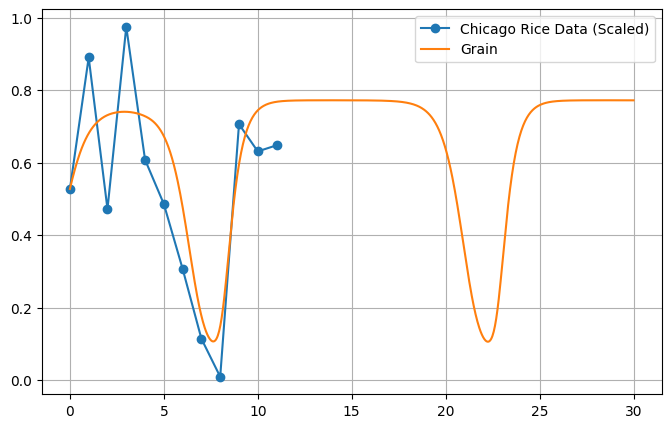


--- Generating Baseline (No Hunting) Graph ---


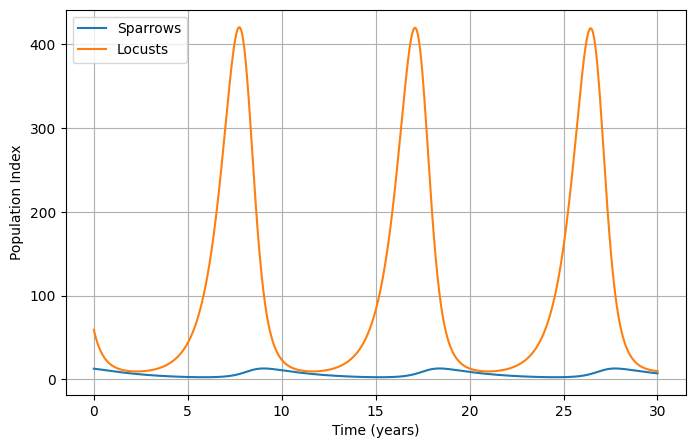

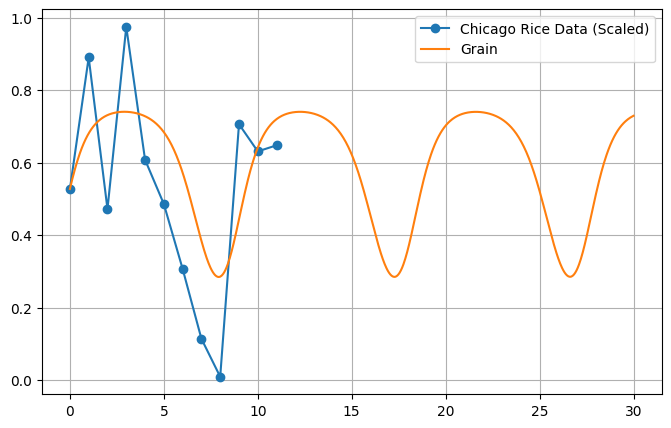

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math
from scipy.stats import qmc
import warnings
import time
import traceback

# Suppress runtime warnings during optimization
warnings.filterwarnings('error', category=RuntimeWarning)
warnings.filterwarnings('ignore')

# --- Data Values ---
years = [1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965]

unscaled_nice = [-39.69, -7.51, -44.61, 0.0, -32.53, -43.36, -59.23, -76.33, -85.63, -23.83, -30.49, -29.00]
rice_estimate_1958 = 59_400_000
rice_decrease_percent = 31.3

coefficients_kg = np.array(unscaled_nice) * 1_000_000
baseline_production = rice_estimate_1958 / (1 - (rice_decrease_percent / 100))
positive_rice_production = baseline_production + coefficients_kg

# Global failure tracking for debugging
failure_reasons = {"extinction": 0, "grain_survival": 0, "structural": 0, "locust_instability": 0, "start_gap": 0, "flatline": 0}

def system(t, y, Eh, *params):
    S, L, G = y
    lam, a2, b1, b3, b5, c1, c2, c3, r_g, K_l, a3, b2, b4 = params

    current_Eh = Eh if 4.0 <= t <= 6.5 else 0.0

    def f(L):
        return b1 + (b2 * L**2) / (b3**2 + L**2)

    dS = (lam * S * L) / (K_l + L) + (a2 * G * S) - (a3 * S) - (current_Eh * S)
    dL = f(L) * L - (b4 * L) - (b5 * S * L)
    dG = (r_g * (1 - G)) - (c1 * G * S) - (c2 * G * L) - (c3 * G)

    return [dS, dL, dG]

numYears = 30
stepsPerYear = 30
t_span = (0, numYears)
t_eval = np.linspace(0, numYears, stepsPerYear * numYears)
params = [0.001, 0.00, 1.50, 0.01, 0.005, 0.001, 0.005, 0.05, 1.0, 5.0, 0.33, 0.225, 1.0]

def run_simulation(S0, L0, G0, Eh=0.0, graphSL=False, graphGrains=False, useChicago=True):
    y0 = [S0, L0, G0]
    sol = solve_ivp(system, t_span, y0, t_eval=t_eval, args=(Eh, *params), method='LSODA', atol=1e-9, rtol=1e-7)

    # Dynamically scale data so the first historical point perfectly matches the starting G0
    scaling_factor = G0 / positive_rice_production[0]
    scaled_rice_data = positive_rice_production * scaling_factor

    if graphSL:
        plt.figure(figsize=(8,5))
        plt.plot(sol.t, sol.y[0], label='Sparrows')
        plt.plot(sol.t, sol.y[1], label='Locusts')
        plt.xlabel('Time (years)')
        plt.ylabel('Population Index')
        plt.legend()
        plt.grid(True)
        plt.show()

    if graphGrains:
        plt.figure(figsize=(8,5))
        if useChicago:
            plt.plot(list(range(12)), scaled_rice_data, 'o-', label='Chicago Rice Data (Scaled)')
        plt.plot(sol.t, sol.y[2], label='Grain')
        plt.legend()
        plt.grid(True)
        plt.show()

    simGrains = sol.y[2]
    from sklearn.metrics import r2_score as r2
    grainsForFit = [simGrains[i] for i in range(0, 12 * stepsPerYear, stepsPerYear)]

    return r2(scaled_rice_data, grainsForFit), simGrains

def run_lhs_simulations(n_samples_pass1=20000, n_samples_pass2=300):
    weight_fit, weight_osc = 0.80, 0.20

    def evaluate_params(param_set):
        global failure_reasons, params
        lam, a2, b1, b3, b5, c1, c2, c3, r_g, K_l, a3, b2, b4, Eh_val = param_set
        params = [lam, a2, b1, b3, b5, c1, c2, c3, r_g, K_l, a3, b2, b4]

        try:
            burn_sol = solve_ivp(system, (0, 30), [5.0, 10.0, 0.5], t_eval=t_eval, args=(0.0, *params), method='LSODA')
            if not burn_sol.success:
                return -float('inf'), None

            half = len(t_eval) // 2
            S_osc, L_osc, G_osc = burn_sol.y[0, half:], burn_sol.y[1, half:], burn_sol.y[2, half:]

            if np.min(S_osc) < 0.01 or np.min(L_osc) < 0.01:
                failure_reasons["extinction"] += 1
                return -float('inf'), None
            if np.mean(G_osc) < 0.4:
                failure_reasons["grain_survival"] += 1
                return -float('inf'), None
            if np.mean(L_osc) <= np.mean(S_osc):
                failure_reasons["structural"] += 1
                return -float('inf'), None
            if np.max(L_osc) > 200 * np.min(L_osc):
                failure_reasons["locust_instability"] += 1
                return -float('inf'), None

            best_p_score, best_p_start = -float('inf'), None
            found_start = False

            for idx in range(len(t_eval)-150, len(t_eval), 5):
                S0, L0, G0 = burn_sol.y[:, idx]

                scaling_factor = G0 / positive_rice_production[0]
                scaled_rice_data = positive_rice_production * scaling_factor

                if np.max(scaled_rice_data) > 0.99:
                    continue

                found_start = True
                baseline_range = np.max(scaled_rice_data[:4]) - np.min(scaled_rice_data[:4])

                fit, simGrains = run_simulation(S0, L0, G0, Eh=Eh_val)

                if np.min(simGrains[120:195]) > (simGrains[0] * 0.99):
                    continue

                sim_range = np.max(G_osc) - np.min(G_osc)
                osc_score = max(0, 1.0 - (sim_range / (2 * baseline_range))) if sim_range > baseline_range else 1.0

                combined = (weight_fit * fit) + (weight_osc * osc_score)
                if combined > best_p_score:
                    best_p_score, best_p_start = combined, (S0, L0, G0)

            if not found_start:
                failure_reasons["start_gap"] += 1
            if found_start and best_p_score == -float('inf'):
                failure_reasons["flatline"] += 1

            return best_p_score, best_p_start

        except Exception:
            return -float('inf'), None

    print(f"Starting Pass 1 ({n_samples_pass1} samples)...")

    log_bounds = [
        (-1, 2.5), (-4, 0), (0.05, 1.2), (-3, -1), (-5, -0.3),
        (-5, -1), (-5, -1), (-3, 0), (-1, 1), (-1, 4), (-1, 0),
        (-2, 1), (-1, 1), (-1, 0.0)
    ]

    sampler1 = qmc.LatinHypercube(d=14)
    scaled1 = qmc.scale(sampler1.random(n=n_samples_pass1), [b[0] for b in log_bounds], [b[1] for b in log_bounds])

    valid_count, best_s, best_p, best_m = 0, -float('inf'), None, None
    b1_mark = max(1, n_samples_pass1 // 10)

    for i, p_log in enumerate(scaled1):
        p = [10**x for x in p_log]
        score, start_vec = evaluate_params(p)
        if score > -float('inf'):
            valid_count += 1
        if score > best_s:
            best_s, best_p, best_m = score, p, start_vec
        if (i + 1) % b1_mark == 0:
            print(f"Pass 1: {((i + 1) // b1_mark) * 10}% complete. Valid: {valid_count}")
            print(f"  Failures -> Extinction: {failure_reasons['extinction']}, Structural: {failure_reasons['structural']}, Stability: {failure_reasons['locust_instability']}")

    if best_p is None:
        return None, None, None

    print(f"Pass 1 Best: {best_s:.4f}. Starting Pass 2...")
    l_bounds = [(x*0.7, x*1.3) for x in best_p]
    scaled2 = qmc.scale(qmc.LatinHypercube(d=14).random(n=n_samples_pass2), [b[0] for b in l_bounds], [b[1] for b in l_bounds])

    for i, p in enumerate(scaled2):
        score, start_vec = evaluate_params(p)
        if score > best_s:
            best_s, best_p, best_m = score, p, start_vec

    return best_p, best_s, best_m

if __name__ == "__main__":
    bestParams, finalScore, midpoint = run_lhs_simulations()
    if midpoint:
        print(bestParams)
        params = bestParams[:-1]
        print(f"\nOptimization Complete. Best Score: {finalScore}")

        print("\n--- Generating Hunting Simulation Graph ---")
        run_simulation(*midpoint, Eh=bestParams[-1], graphSL=True, graphGrains=True)

        print("\n--- Generating Baseline (No Hunting) Graph ---")
        run_simulation(*midpoint, Eh=0.0, graphSL=True, graphGrains=True)

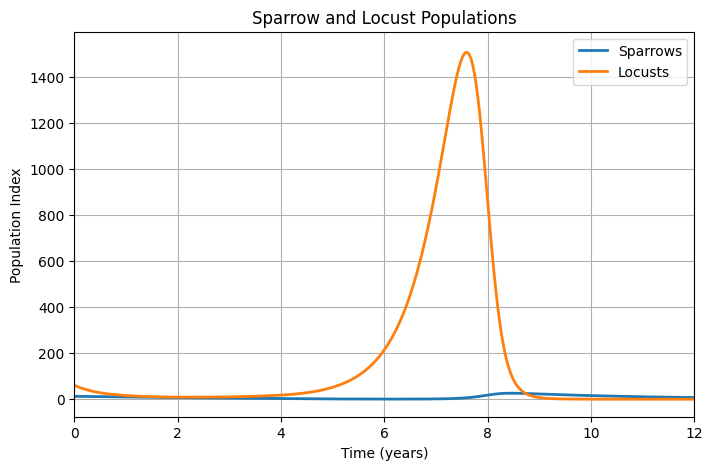

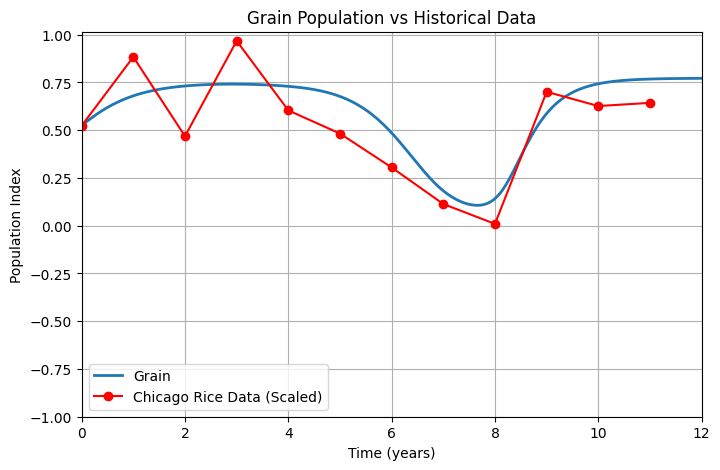

In [7]:
def graph_from_params(param_array):
    from sklearn.metrics import r2_score as r2

    # Unpack the array: first 13 are system params, the last is Eh
    *sys_params, Eh = param_array

    # --- 1. Burn-in Phase ---
    # Run 30 years with Eh=0.0 to establish natural oscillations
    burn_sol = solve_ivp(system, (0, 30), [5.0, 10.0, 0.5], t_eval=t_eval, args=(0.0, *sys_params), method='LSODA', atol=1e-9, rtol=1e-7)

    if not burn_sol.success:
        print("Burn-in simulation failed to converge.")
        return

    # --- 2. Search for the Optimal Starting Point ---
    best_p_score, best_p_start = -float('inf'), None
    weight_fit, weight_osc = 0.80, 0.20
    half = len(t_eval) // 2
    G_osc = burn_sol.y[2, half:]

    # Evaluate the last 150 steps exactly like the optimizer does
    for idx in range(len(t_eval)-150, len(t_eval), 5):
        S0, L0, G0 = burn_sol.y[:, idx]

        scaling_factor = G0 / positive_rice_production[0]
        scaled_rice_data = positive_rice_production * scaling_factor

        if np.max(scaled_rice_data) > 0.99:
            continue

        # Temporary run to evaluate the fit of this starting point
        temp_sol = solve_ivp(system, t_span, [S0, L0, G0], t_eval=t_eval, args=(Eh, *sys_params), method='LSODA', atol=1e-9, rtol=1e-7)
        simGrains = temp_sol.y[2]

        if np.min(simGrains[120:195]) > (simGrains[0] * 0.99):
            continue

        # Calculate oscillation and fit scores
        baseline_range = np.max(scaled_rice_data[:4]) - np.min(scaled_rice_data[:4])
        sim_range = np.max(G_osc) - np.min(G_osc)
        osc_score = max(0, 1.0 - (sim_range / (2 * baseline_range))) if sim_range > baseline_range else 1.0

        grainsForFit = [simGrains[i] for i in range(0, 12 * stepsPerYear, stepsPerYear)]
        fit = r2(scaled_rice_data, grainsForFit)

        combined = (weight_fit * fit) + (weight_osc * osc_score)

        if combined > best_p_score:
            best_p_score, best_p_start = combined, [S0, L0, G0]

    if best_p_start is None:
        print("Could not find a valid starting point from the burn-in phase that meets the constraints.")
        return

    # --- 3. Final Simulation & Plotting ---
    S0, L0, G0 = best_p_start
    final_sol = solve_ivp(system, t_span, [S0, L0, G0], t_eval=t_eval, args=(Eh, *sys_params), method='LSODA', atol=1e-9, rtol=1e-7)

    # Rescale the Chicago data one final time for the plot
    scaling_factor = G0 / positive_rice_production[0]
    scaled_rice_data = positive_rice_production * scaling_factor

    # --- Graph 1: Sparrows and Locusts ---
    plt.figure(figsize=(8, 5))
    plt.plot(final_sol.t, final_sol.y[0], label='Sparrows', linewidth=2)
    plt.plot(final_sol.t, final_sol.y[1], label='Locusts', linewidth=2)
    plt.xlim(0, 12)
    plt.xlabel('Time (years)')
    plt.ylabel('Population Index')
    plt.title('Sparrow and Locust Populations')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Graph 2: Grain and Historical Data ---
    plt.figure(figsize=(8, 5))
    plt.plot(final_sol.t, final_sol.y[2], label='Grain', linewidth=2)
    plt.plot(list(range(12)), scaled_rice_data, 'o-', label='Chicago Rice Data (Scaled)', color='red')
    plt.xlim(0, 12)
    plt.xlabel('Time (years)')
    plt.ylabel('Population Index')
    plt.ylim(bottom=-1)
    plt.title('Grain Population vs Historical Data')
    plt.legend()
    plt.grid(True)
    plt.show()

# Execution call using your provided array
graph_from_params([7.18000191e+00, 3.90613857e-03, 1.65339085e+00, 7.26296455e-03,
 2.65769887e-01, 1.45406889e-05, 8.10024894e-03, 4.41319261e-01,
 1.49504701e+00, 1.81012354e+03, 3.85869716e-01, 2.20611557e-01,
 2.14437533e-01, 7.27467408e-01])